# Map Coloring Problem

## Problem Description



**Map Diagram:**
```
-----------------------------
|  green  | yellow | green  |
|---------------------------|
|  blue   | white  | blue   |
-----------------------------
```

**Goal:** Choose colors so that adjacent planar pieces have different colors.

**State:** Describes colored pieces and selected color.

**Initial State:** Map with available colors (g, y, b, w) and empty assignments.

**Actions:**
- `color(piece, color)` - colors a map piece with chosen color

**Transition Map:**
- `color()` colors the piece if neighboring piece is not of the same color
- `color()` returns failure if color is present in neighboring piece

**Goal Test:** Test if the map is completely colored.

**Path Cost:** Every coloring action costs 1. Sum of coloring actions.

## Implementation

### Imports

In [2]:
import sys
sys.path.append('../..')

from search4e import (
    Problem, breadth_first_search, depth_first_bfs, 
    uniform_cost_search, astar_search, path_actions, path_states, report
)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

print("Modules imported successfully!")

Modules imported successfully!


### ColoringProblem Class

This class represents the map coloring problem as a search problem:
- **State:** Tuple of (piece, color) assignments
- **Actions:** (piece, color) tuples for uncolored pieces with valid colors
- **Result:** Add a new color assignment to the state
- **Goal Test:** All pieces are colored

In [3]:
class ColoringProblem(Problem):
    """Map coloring problem as a search problem.
    State is a tuple of (piece, color) assignments.
    Actions are (piece, color) tuples for uncolored pieces.
    """
    
    def __init__(self, pieces, colors, adjacencies, initial=()):
        """
        Args:
            pieces: List of piece names
            colors: List of available colors
            adjacencies: Dict mapping piece -> list of adjacent pieces
            initial: Initial state (empty tuple for no assignments)
        """
        super().__init__(initial)
        self.pieces = pieces
        self.colors = colors
        self.adjacencies = adjacencies
        self.goal = None  # Goal is determined by is_goal method
    
    def actions(self, state):
        """Return available (piece, color) actions for uncolored pieces."""
        # Get currently colored pieces
        colored = {piece for piece, color in state}
        
        # Find first uncolored piece
        uncolored = [p for p in self.pieces if p not in colored]
        if not uncolored:
            return []
        
        piece = uncolored[0]  # Color pieces one at a time
        
        # Get colors used by adjacent pieces
        adjacent_colors = set()
        for adj_piece in self.adjacencies.get(piece, []):
            for p, c in state:
                if p == adj_piece:
                    adjacent_colors.add(c)
                    break
        
        # Return valid colors (not used by adjacent pieces)
        valid_colors = [c for c in self.colors if c not in adjacent_colors]
        return [(piece, color) for color in valid_colors]
    
    def result(self, state, action):
        """Return new state with the action (piece, color) added."""
        return tuple(list(state) + [action])
    
    def is_goal(self, state):
        """Goal is reached when all pieces are colored."""
        colored = {piece for piece, color in state}
        return len(colored) == len(self.pieces)
    
    def action_cost(self, s, action, s1):
        """Each coloring action costs 1."""
        return 1

### Problem Instance

Create the map coloring problem with:
- 6 pieces (regions in a 2x3 grid)
- 4 colors: green (g), yellow (y), blue (b), white (w)
- Adjacency constraints based on the grid structure

In [4]:
# Define the map structure (2x3 grid)
# Top row: P1, P2, P3
# Bottom row: P4, P5, P6

pieces = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
colors = ['g', 'y', 'b', 'w']  # green, yellow, blue, white

# Define adjacencies (pieces that share a border)
adjacencies = {
    'P1': ['P2', 'P4'],          # Top-left
    'P2': ['P1', 'P3', 'P5'],    # Top-middle
    'P3': ['P2', 'P6'],          # Top-right
    'P4': ['P1', 'P5'],          # Bottom-left
    'P5': ['P2', 'P4', 'P6'],    # Bottom-middle
    'P6': ['P3', 'P5']           # Bottom-right
}

# Create the coloring problem
coloring_problem = ColoringProblem(pieces, colors, adjacencies)

print(f"Pieces: {coloring_problem.pieces}")
print(f"Colors: {coloring_problem.colors}")
print(f"Adjacencies:")
for piece, neighbors in adjacencies.items():
    print(f"  {piece}: {neighbors}")

Pieces: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
Colors: ['g', 'y', 'b', 'w']
Adjacencies:
  P1: ['P2', 'P4']
  P2: ['P1', 'P3', 'P5']
  P3: ['P2', 'P6']
  P4: ['P1', 'P5']
  P5: ['P2', 'P4', 'P6']
  P6: ['P3', 'P5']


### Test Actions

Explore available actions from the initial state and test state transitions.

In [5]:
# Test available actions from initial state
initial_actions = coloring_problem.actions(coloring_problem.initial)
print(f"Available actions from initial state:")
print(f"  State: {coloring_problem.initial}")
print(f"  Actions: {initial_actions}")

# Test a few state transitions
state1 = coloring_problem.result(coloring_problem.initial, ('P1', 'g'))
print(f"\nAfter coloring P1 green:")
print(f"  State: {state1}")
actions1 = coloring_problem.actions(state1)
print(f"  Available actions: {actions1}")

state2 = coloring_problem.result(state1, ('P2', 'y'))
print(f"\nAfter coloring P2 yellow:")
print(f"  State: {state2}")
actions2 = coloring_problem.actions(state2)
print(f"  Available actions: {actions2}")

# Check if goal is reached
print(f"\nIs initial state a goal? {coloring_problem.is_goal(coloring_problem.initial)}")
print(f"Is state1 a goal? {coloring_problem.is_goal(state1)}")
print(f"Is state2 a goal? {coloring_problem.is_goal(state2)}")

Available actions from initial state:
  State: ()
  Actions: [('P1', 'g'), ('P1', 'y'), ('P1', 'b'), ('P1', 'w')]

After coloring P1 green:
  State: (('P1', 'g'),)
  Available actions: [('P2', 'y'), ('P2', 'b'), ('P2', 'w')]

After coloring P2 yellow:
  State: (('P1', 'g'), ('P2', 'y'))
  Available actions: [('P3', 'g'), ('P3', 'b'), ('P3', 'w')]

Is initial state a goal? False
Is state1 a goal? False
Is state2 a goal? False


### Solve with Breadth-First Search

Use breadth-first search to find a solution to the map coloring problem.

In [6]:
# Solve using breadth-first search
solution = breadth_first_search(coloring_problem)

if solution:
    actions = path_actions(solution)
    states = path_states(solution)
    
    print("Solution found!")
    print(f"\nNumber of steps: {len(actions)}")
    print(f"Total cost: {solution.path_cost}")
    
    print("\nSolution path:")
    for i, (state, action) in enumerate(zip(states, actions + [None])):
        if i == 0:
            print(f"Step {i}: Initial state = {state}")
        else:
            print(f"Step {i}: {action} → {state}")
            if action is None:
                print("  (GOAL REACHED)")
    
    # Print final coloring
    print("\nFinal coloring:")
    final_state = states[-1]
    for piece, color in sorted(final_state):
        color_name = {'g': 'green', 'y': 'yellow', 'b': 'blue', 'w': 'white'}.get(color, color)
        print(f"  {piece}: {color_name}")
else:
    print("No solution found!")

Solution found!

Number of steps: 6
Total cost: 6

Solution path:
Step 0: Initial state = ()
Step 1: ('P2', 'y') → (('P1', 'g'),)
Step 2: ('P3', 'g') → (('P1', 'g'), ('P2', 'y'))
Step 3: ('P4', 'y') → (('P1', 'g'), ('P2', 'y'), ('P3', 'g'))
Step 4: ('P5', 'g') → (('P1', 'g'), ('P2', 'y'), ('P3', 'g'), ('P4', 'y'))
Step 5: ('P6', 'y') → (('P1', 'g'), ('P2', 'y'), ('P3', 'g'), ('P4', 'y'), ('P5', 'g'))
Step 6: None → (('P1', 'g'), ('P2', 'y'), ('P3', 'g'), ('P4', 'y'), ('P5', 'g'), ('P6', 'y'))
  (GOAL REACHED)

Final coloring:
  P1: green
  P2: yellow
  P3: green
  P4: yellow
  P5: green
  P6: yellow


### Algorithm Comparison

Compare different search algorithms on the map coloring problem.

In [7]:
import time

def compare_algorithms(problem):
    """Compare different search algorithms on the given problem."""
    algorithms = {
        'Breadth-First': breadth_first_search,
        'Depth-First': depth_first_bfs,
        'Uniform-Cost': uniform_cost_search,
        'A* Search': astar_search,
    }
    
    results = []
    
    print("Algorithm Comparison:\n" + "="*70)
    
    for name, algorithm in algorithms.items():
        try:
            start_time = time.time()
            solution = algorithm(problem)
            end_time = time.time()
            
            if solution:
                actions = path_actions(solution)
                cost = solution.path_cost
                time_taken = (end_time - start_time) * 1000  # Convert to milliseconds
                
                results.append({
                    'Algorithm': name,
                    'Steps': len(actions),
                    'Cost': cost,
                    'Time (ms)': f'{time_taken:.2f}'
                })
                
                print(f"{name:20} | Steps: {len(actions):2} | Cost: {cost:4.0f} | Time: {time_taken:6.2f} ms")
            else:
                print(f"{name:20} | No solution found")
        except Exception as e:
            print(f"{name:20} | Error: {str(e)}")
    
    return results

results = compare_algorithms(coloring_problem)

Algorithm Comparison:
Breadth-First        | Steps:  6 | Cost:    6 | Time:   1.60 ms
Depth-First          | Steps:  6 | Cost:    6 | Time:   0.16 ms
Uniform-Cost         | Steps:  6 | Cost:    6 | Time:   8.20 ms
A* Search            | Steps:  6 | Cost:    6 | Time:   3.09 ms


### Performance Report

Detailed performance analysis of the solution.

In [8]:
def performance_report(problem, solution):
    """Generate a detailed performance report."""
    if not solution:
        print("No solution to report on")
        return
    
    actions = path_actions(solution)
    states = path_states(solution)
    final_state = states[-1]
    
    print("=" * 70)
    print("PERFORMANCE REPORT: Map Coloring Problem")
    print("=" * 70)
    
    print(f"\nProblem Configuration:")
    print(f"  Number of pieces: {len(problem.pieces)}")
    print(f"  Available colors: {problem.colors}")
    print(f"  Pieces: {problem.pieces}")
    
    print(f"\nSolution Metrics:")
    print(f"  Total Steps: {len(actions)}")
    print(f"  Total Path Cost: {solution.path_cost}")
    print(f"  Solution Depth: {len(actions)}")
    
    # Analyze final coloring
    piece_colors = {piece: color for piece, color in final_state}
    color_usage = {}
    for color in problem.colors:
        count = sum(1 for c in piece_colors.values() if c == color)
        color_usage[color] = count
    
    print(f"\nColor Usage:")
    color_names = {'g': 'green', 'y': 'yellow', 'b': 'blue', 'w': 'white'}
    for color, count in sorted(color_usage.items()):
        if count > 0:
            color_name = color_names.get(color, color)
            print(f"  {color_name:7} ({color}): {count} pieces")
    
    print(f"\nFinal Coloring Assignment:")
    for piece in sorted(problem.pieces):
        color = piece_colors[piece]
        color_name = color_names.get(color, color)
        print(f"  {piece}: {color_name}")
    
    # Verify constraints
    print(f"\nConstraint Verification:")
    violations = 0
    for piece, neighbors in problem.adjacencies.items():
        piece_color = piece_colors[piece]
        for neighbor in neighbors:
            neighbor_color = piece_colors[neighbor]
            if piece_color == neighbor_color:
                violations += 1
                print(f"  VIOLATION: {piece} and {neighbor} both have color {piece_color}")
    
    if violations == 0:
        print(f"  ✓ All constraints satisfied! No adjacent pieces have the same color.")
    else:
        print(f"  ✗ Found {violations} constraint violations!")
    
    print(f"\nEfficiency:")
    print(f"  Average cost per step: {solution.path_cost / len(actions):.2f}")
    print(f"  Colors used: {sum(1 for c in color_usage.values() if c > 0)} out of {len(problem.colors)}")
    
    print("\n" + "=" * 70)

performance_report(coloring_problem, solution)

PERFORMANCE REPORT: Map Coloring Problem

Problem Configuration:
  Number of pieces: 6
  Available colors: ['g', 'y', 'b', 'w']
  Pieces: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

Solution Metrics:
  Total Steps: 6
  Total Path Cost: 6
  Solution Depth: 6

Color Usage:
  green   (g): 3 pieces
  yellow  (y): 3 pieces

Final Coloring Assignment:
  P1: green
  P2: yellow
  P3: green
  P4: yellow
  P5: green
  P6: yellow

Constraint Verification:
  ✓ All constraints satisfied! No adjacent pieces have the same color.

Efficiency:
  Average cost per step: 1.00
  Colors used: 2 out of 4



### Visualization

Visualize the map coloring solution as a grid with colored regions.

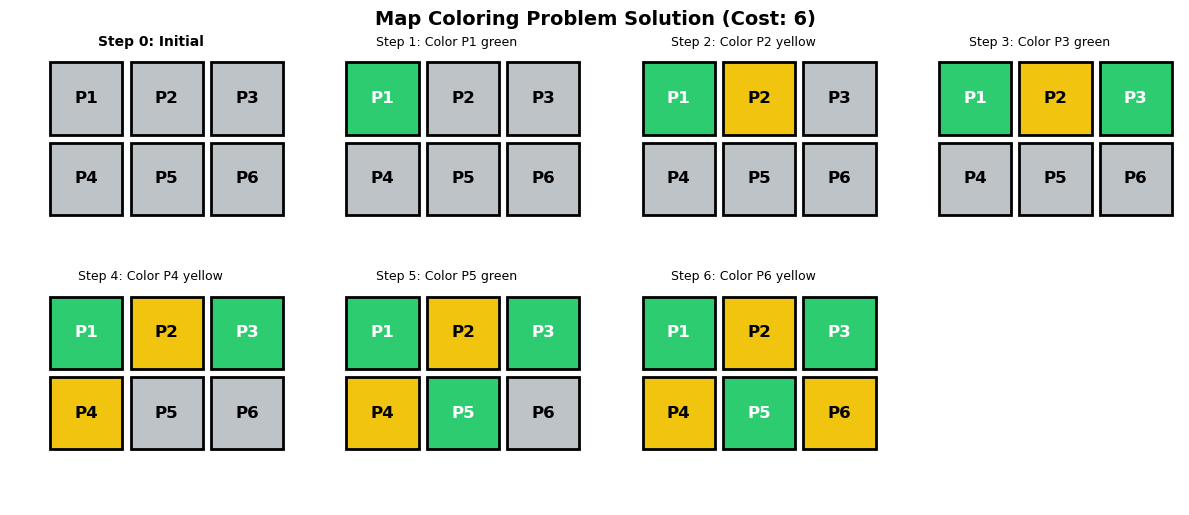

In [9]:
def visualize_coloring_solution(problem, solution):
    """Visualize the map coloring solution as a grid."""
    if not solution:
        print("No solution to visualize")
        return
    
    states = path_states(solution)
    actions = path_actions(solution)
    
    # Color mapping
    color_map = {
        'g': '#2ecc71',  # green
        'y': '#f1c40f',  # yellow
        'b': '#3498db',  # blue
        'w': '#ecf0f1',  # white (light gray)
        None: '#bdc3c7'  # gray for uncolored
    }
    
    # Grid layout (2 rows x 3 columns)
    grid_positions = {
        'P1': (0, 1), 'P2': (1, 1), 'P3': (2, 1),  # Top row
        'P4': (0, 0), 'P5': (1, 0), 'P6': (2, 0)   # Bottom row
    }
    
    num_steps = len(states)
    cols = min(4, num_steps)
    rows = (num_steps + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2.5))
    if num_steps == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for step, (state, ax) in enumerate(zip(states, axes)):
        ax.set_xlim(-0.5, 3)
        ax.set_ylim(-0.5, 2)
        ax.set_aspect('equal')
        ax.axis('off')
        
        # Create color dictionary for current state
        piece_colors = {piece: color for piece, color in state}
        
        # Draw grid pieces
        for piece, (x, y) in grid_positions.items():
            color = piece_colors.get(piece)
            rect = patches.Rectangle((x, y), 0.9, 0.9, 
                                     linewidth=2, 
                                     edgecolor='black',
                                     facecolor=color_map.get(color, color_map[None]))
            ax.add_patch(rect)
            
            # Add piece label
            ax.text(x + 0.45, y + 0.45, piece, 
                   ha='center', va='center', 
                   fontsize=12, fontweight='bold',
                   color='black' if color in ['y', 'w', None] else 'white')
        
        # Title
        if step == 0:
            ax.set_title(f'Step {step}: Initial', fontsize=10, fontweight='bold')
        else:
            action_piece, action_color = actions[step-1]
            color_name = {'g': 'green', 'y': 'yellow', 'b': 'blue', 'w': 'white'}.get(action_color, action_color)
            ax.set_title(f'Step {step}: Color {action_piece} {color_name}', fontsize=9)
    
    # Hide unused subplots
    for i in range(num_steps, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Map Coloring Problem Solution (Cost: {solution.path_cost})', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.show()

# Visualize the solution
visualize_coloring_solution(coloring_problem, solution)